# Stage 01: Data Preparation and Exploratory Data Analysis (EDA)

## Objective
This notebook loads, preprocesses, and explores the synthetic stained-nuclei fluorescence microscopy dataset.
It validates file integrity across all splits (`train`, `val`, `test`), visualizes representative samples from each density regime (`sparse`, `normal`, `dense`, `clustered`), and computes pixel intensity and object count distributions.


In [35]:
# 1. Imports and Environment Setup
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [36]:
# 2. Dynamic Project Path Resolution
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

# Dataset path resolution
DATA_DIR = PROJECT_ROOT / "data" / "nuclei_dataset"
if not DATA_DIR.exists():
    DATA_DIR = PROJECT_ROOT / "nuclei_dataset"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

TRAIN_IMAGES_DIR = TRAIN_DIR / "images"
TRAIN_MASKS_DIR = TRAIN_DIR / "masks"
VAL_IMAGES_DIR = VAL_DIR / "images"
VAL_MASKS_DIR = VAL_DIR / "masks"
TEST_IMAGES_DIR = TEST_DIR / "images"
TEST_MASKS_DIR = TEST_DIR / "masks"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Dataset path :", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())


Project root : C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-03\AI imaging Coding
Dataset path : C:\Users\LOJANA-UOH\OneDrive - University of Hertfordshire\DAwAI\Assignment-03\AI imaging Coding\nuclei_dataset
Dataset exists: True


In [37]:
# 3. Add project root to Python path and import preprocessing module
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_image,
    preprocess_image,
    load_mask,
    validate_dataset_images,
    validate_image_mask_pairs,
)

print("Preprocessing module imported successfully.")


Preprocessing module imported successfully.


In [38]:
# 4. Validate Directory Structure and Dataset Counts
required_directories = {
    "Train images": TRAIN_IMAGES_DIR,
    "Train masks": TRAIN_MASKS_DIR,
    "Validation images": VAL_IMAGES_DIR,
    "Validation masks": VAL_MASKS_DIR,
    "Test images": TEST_IMAGES_DIR,
    "Test masks": TEST_MASKS_DIR,
}

for name, path in required_directories.items():
    print(f"{name:<20}: {'FOUND' if path.exists() else 'MISSING'} ({len(list(path.glob('*.png')))} images)")


Train images        : FOUND (80 images)
Train masks         : FOUND (80 images)
Validation images   : FOUND (20 images)
Validation masks    : FOUND (20 images)
Test images         : FOUND (12 images)
Test masks          : FOUND (12 images)


In [39]:
# 5. Metadata Inspection
metadata_path = DATA_DIR / "metadata.csv"
if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found at: {metadata_path}")

metadata = pd.read_csv(metadata_path)
print("Metadata shape:", metadata.shape)
display(metadata.head(10))


Metadata shape: (112, 7)


,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719
5,train_005,train,clustered,52,0.720140,0.104507,20260720
6,train_006,train,sparse,5,0.786762,0.013840,20260721
7,train_007,train,normal,19,0.702409,0.049591,20260722
8,train_008,train,normal,16,0.643560,0.045654,20260723
9,train_009,train,normal,21,0.737737,0.062454,20260724


In [40]:
# 6. Dataset Summary by Data Split
split_summary = (
    metadata.groupby("split")
    .agg(
        n_images=("image_id", "count"),
        min_objects=("n_objects", "min"),
        mean_objects=("n_objects", "mean"),
        max_objects=("n_objects", "max"),
        mean_intensity=("mean_intensity", "mean"),
        mean_area_fraction=("area_fraction", "mean"),
    )
    .reset_index()
)
print("=== Dataset Summary by Data Split ===")
display(split_summary)

# 7. Dataset Summary by Density Regime
rows = []
for d in ["sparse", "normal", "dense", "clustered"]:
    sub = metadata[metadata["density"] == d]
    c_m, c_s = sub["n_objects"].mean(), sub["n_objects"].std()
    a_m, a_s = sub["area_fraction"].mean() * 100, sub["area_fraction"].std() * 100
    rows.append({
        "Density": d.capitalize(),
        "Images": len(sub),
        "Mean nuclei count": f"{c_m:.2f} ± {c_s:.2f}",
        "Mean area coverage": f"{a_m:.2f}% ± {a_s:.2f}%"
    })

total_c_m, total_c_s = metadata["n_objects"].mean(), metadata["n_objects"].std()
total_a_m, total_a_s = metadata["area_fraction"].mean() * 100, metadata["area_fraction"].std() * 100
rows.append({
    "Density": "Overall",
    "Images": len(metadata),
    "Mean nuclei count": f"{total_c_m:.2f} ± {total_c_s:.2f}",
    "Mean area coverage": f"{total_a_m:.2f}% ± {total_a_s:.2f}%"
})

density_summary_df = pd.DataFrame(rows)
print()
print("=== Dataset Summary by Density Regime ===")
display(density_summary_df)

# 8. Split vs. Density Regime Cross-Tabulation
cross_tab = pd.crosstab(metadata["split"], metadata["density"], margins=True)
ordered_cols = [c for c in ["sparse", "normal", "dense", "clustered", "All"] if c in cross_tab.columns]
ordered_rows = [r for r in ["train", "val", "test", "All"] if r in cross_tab.index]
print()
print("=== Split vs. Density Regime Image Distribution ===")
display(cross_tab.loc[ordered_rows, ordered_cols])


=== Dataset Summary by Data Split ===


,split,n_images,min_objects,mean_objects,max_objects,mean_intensity,mean_area_fraction
0,test,12,8,33.416667,78,0.740878,0.085064
1,train,80,5,32.712500,85,0.738649,0.081785
2,val,20,5,30.800000,81,0.733250,0.075651



=== Dataset Summary by Density Regime ===


,Density,Images,Mean nuclei count,Mean area coverage
0,Sparse,20,8.15 ± 1.76,2.25% ± 0.77%
1,Normal,56,26.27 ± 6.83,7.01% ± 1.99%
2,Dense,18,67.06 ± 13.56,16.94% ± 3.15%
3,Clustered,18,44.06 ± 8.65,9.19% ± 1.56%
4,Overall,112,32.45 ± 20.12,8.10% ± 4.86%



=== Split vs. Density Regime Image Distribution ===


density,sparse,normal,dense,clustered,All
split,,,,,
train,14,40,13,13,80
val,4,10,3,3,20
test,2,6,2,2,12
All,20,56,18,18,112


Processed image shape: (256, 256) | dtype: float32 | Range: [0.000, 0.347]
Processed mask shape : (256, 256) | dtype: uint8 | Values: [0 1]


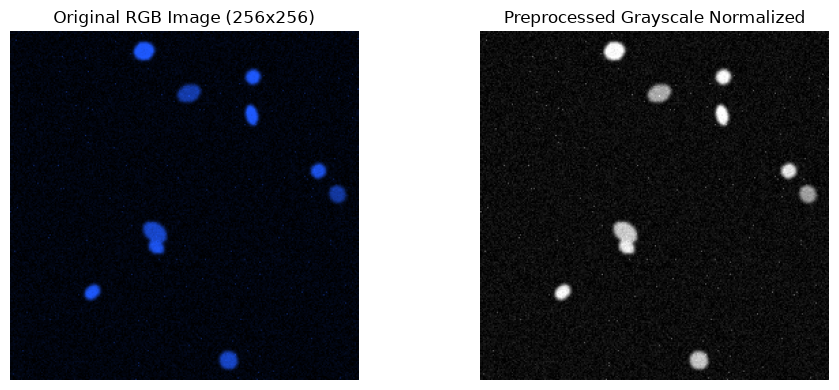

In [41]:
# 9. Image Preprocessing Verification
sample_image_path = TRAIN_IMAGES_DIR / "train_000.png"
sample_mask_path = TRAIN_MASKS_DIR / "train_000.png"

processed_image = preprocess_image(sample_image_path)
processed_mask = load_mask(sample_mask_path)

print("Processed image shape:", processed_image.shape, "| dtype:", processed_image.dtype, "| Range:", f"[{processed_image.min():.3f}, {processed_image.max():.3f}]")
print("Processed mask shape :", processed_mask.shape, "| dtype:", processed_mask.dtype, "| Values:", np.unique(processed_mask))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(load_image(sample_image_path))
axes[0].set_title("Original RGB Image (256x256)")
axes[0].axis("off")

axes[1].imshow(processed_image, cmap="gray")
axes[1].set_title("Preprocessed Grayscale Normalized")
axes[1].axis("off")
plt.tight_layout()
plt.show()


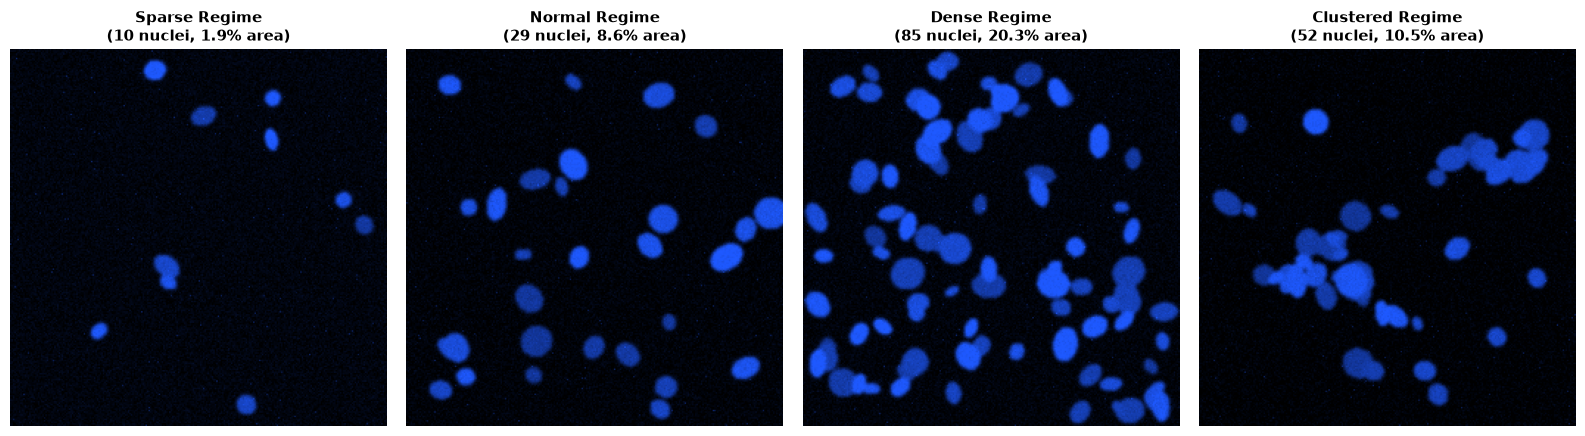

In [42]:
# 8. Visual Exploration Across Density Regimes
density_classes = ["sparse", "normal", "dense", "clustered"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, density in zip(axes, density_classes):
    sample_meta = metadata[(metadata["split"] == "train") & (metadata["density"] == density)].iloc[0]
    img_id = sample_meta["image_id"]
    img_path = TRAIN_IMAGES_DIR / f"{img_id}.png"
    rgb_img = load_image(img_path)

    ax.imshow(rgb_img)
    ax.set_title(f"{density.capitalize()} Regime\n({sample_meta['n_objects']} nuclei, {sample_meta['area_fraction']*100:.1f}% area)", fontsize=11, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_density_samples.png", dpi=300, bbox_inches="tight")
plt.show()


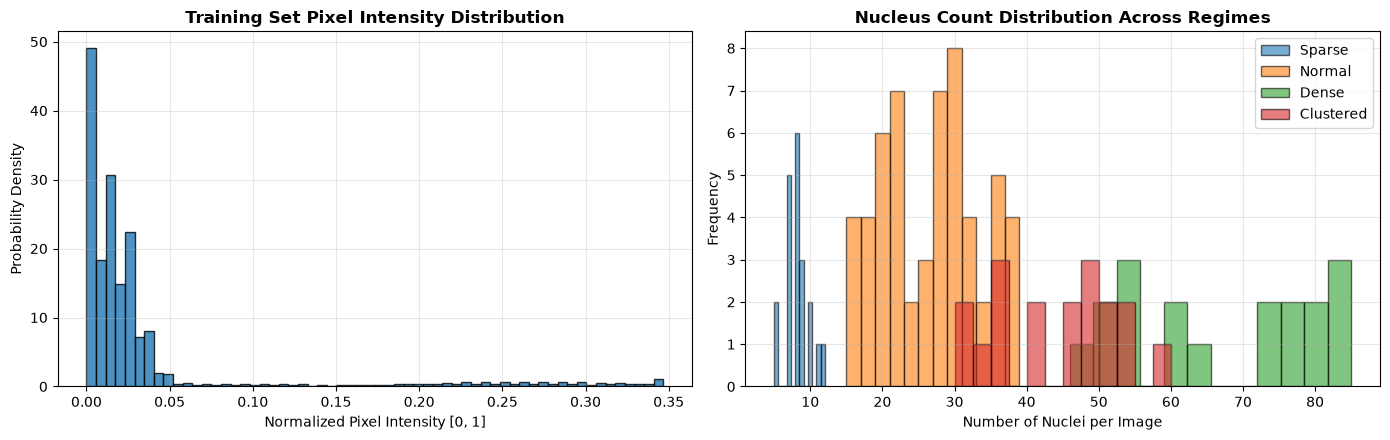

In [43]:
# 9. Pixel Intensity & Nucleus Count Distributions
all_train_pixels = []
for image_path in sorted(TRAIN_IMAGES_DIR.glob("*.png")):
    all_train_pixels.append(preprocess_image(image_path).ravel())
all_train_pixels = np.concatenate(all_train_pixels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(all_train_pixels, bins=60, color="#1f77b4", edgecolor="black", alpha=0.8, density=True)
axes[0].set_title("Training Set Pixel Intensity Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Normalized Pixel Intensity [0, 1]")
axes[0].set_ylabel("Probability Density")
axes[0].grid(True, alpha=0.3)

for density in density_classes:
    sub = metadata[metadata["density"] == density]["n_objects"]
    axes[1].hist(sub, bins=12, alpha=0.6, label=density.capitalize(), edgecolor="black")
axes[1].set_title("Nucleus Count Distribution Across Regimes", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Nuclei per Image")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "eda_intensity_histogram.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Summary
The synthetic stained-nuclei dataset is validated and standardized to 256x256 grayscale float32 tensors $[0, 1]$. Bimodal intensity characteristics and variable density distributions have been quantified and saved to `outputs/figures/`.
